# Bruit

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
plt.style.use('../signal.mplstyle')

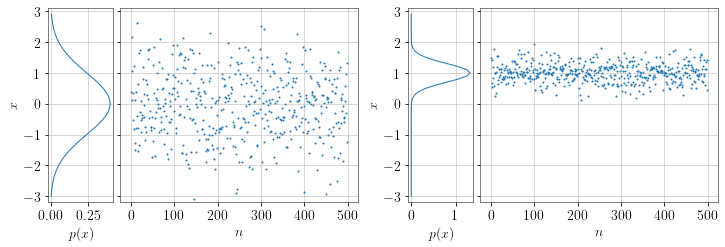

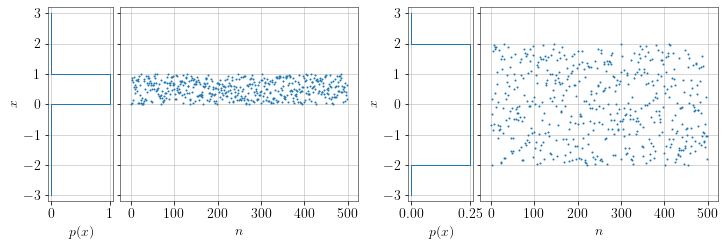

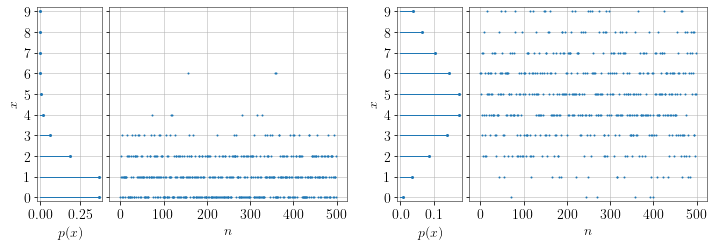

In [2]:
# Réalisations de divers bruits blanc

def myplot(b, pdf1, pdf2, real1, real2, filename, xl, stemize):
    
    pdfs = [pdf1, pdf2]
    reals = [real1, real2]

    # Figure
    fig = plt.figure(figsize=(10, 3))
    
    for i in range(2):
        
        pdf = pdfs[i]
        real = reals[i]
        
        # Densité de probabilité
        
        ax_pdf = plt.axes([0.1+0.5*i, 0.1, 0.09, 0.9])
        for side in ['bottom', 'top', 'right', 'left']:
            ax_pdf.spines[side].set_color('k')
            ax_pdf.spines[side].set_linewidth(0.5)
        ax_pdf.set_ylim(xl)
        ax_pdf.grid(linewidth=0.5)

        if stemize==1:
            plt.plot(pdf, b, marker='o', markerfacecolor="tab:blue", markersize=2, linestyle="none")
            x = np.array([pdf])
            X = np.concatenate((x*0, x))
            y = np.array([b])
            Y = np.concatenate((y, y))
            plt.figure
            plt.plot(X, Y, 'tab:blue', linewidth=1)
        elif stemize==2:
            plt.plot(pdf, b, 'tab:blue', linewidth=1)
        else:
            plt.plot(pdf, b, 'tab:blue', linewidth=1)
    
        plt.xticks(fontsize=14)
        plt.yticks(np.arange(np.around(xl[0]), np.around(xl[1])+1, 1), fontsize=14)
        plt.xlabel('$p(x)$', fontsize=14)
        plt.ylabel('$x$', fontsize=14)

        # Réalisations
    
        ax_real = plt.axes([0.2+0.5*i, 0.1, 0.33, 0.9])
        for side in ['bottom', 'top', 'right', 'left']:
            ax_real.spines[side].set_color('k')
            ax_real.spines[side].set_linewidth(0.5)
        ax_real.set_ylim(xl)
        ax_real.set_yticklabels([])
        ax_real.grid(linewidth=0.5)
    
        plt.plot(real,'.', markerfacecolor="tab:blue", markersize=2)
    
        plt.xticks(np.arange(0, N+1, 100), fontsize=14)
        plt.yticks(np.arange(np.around(xl[0]), np.around(xl[1])+1, 1), fontsize=14)
        plt.xlabel('$n$', fontsize=14)

    # Enregistrement
#     glue("G:ssp:" + filename, fig, display=False)
    plt.savefig(f"loi-{filename}.svg")


def rect(n):
    return np.where(np.abs(n)<=.5, 1, 0)


N = 500;

# PDF normale
b = np.arange(-3, 3, 0.1)
mu, sig = 0, 1
pdf1 = np.exp( -(b-mu)**2/2/sig**2 ) / np.sqrt(2*np.pi*sig**2)
real1 = np.random.randn(N)*sig + mu
mu, sig = 1, 0.3
pdf2 = np.exp( -(b-mu)**2/2/sig**2 ) / np.sqrt(2*np.pi*sig**2)
real2 = np.random.randn(N)*sig + mu
myplot(b, pdf1, pdf2, real1, real2, 'normale', [b[0]-.2, b[-1]+.2], 0)

# PDF uniforme
# b = np.arange(-3, 3, 0.1)
b = np.array([-3, -2, -2, 0, 0, 1, 1, 2, 2, 3])
x1, x2 = 0, 1
d = (x1+x2)/2
T = x2-x1
# pdf1 = rect((b-d)/T)/T
pdf1 = np.array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])
real1 = np.random.rand(N)*(x2-x1) + x1
x1, x2 = -2, 2
d = (x1+x2)/2
T = x2-x1
# pdf2 = rect((b-d)/T)/T
pdf2 = np.array([0, 0, 1/4, 1/4, 1/4, 1/4, 1/4, 1/4, 0, 0])
real2 = np.random.rand(N)*(x2-x1) + x1;
myplot(b, pdf1, pdf2, real1, real2, 'uniforme', [b[0]-.2, b[-1]+.2], 2)

# PDF Poisson
b = np.arange(0,10)
lbd = 1
pdf1 = np.power(lbd,b) / factorial(b) * np.exp(-lbd)
real1 = np.random.poisson(lbd, N)
lbd = 5
pdf2 = np.power(lbd,b) / factorial(b) * np.exp(-lbd)
real2 = np.random.poisson(lbd, N)
myplot(b, pdf1, pdf2, real1, real2, 'poisson', [b[0]-.2, b[-1]+.2], 1)

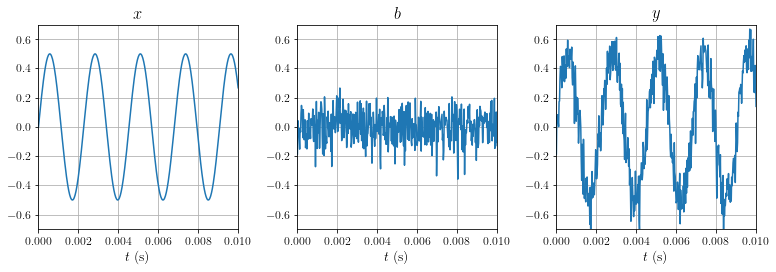

In [15]:
# Illustration du bruit gaussien

# Sinusoïde
fe = int(44.1e3)
t = np.arange(0,1.5,1/fe)
x = .5 * np.sin(2*np.pi*440*t)

# Bruit
b = np.random.normal(0, .1, len(x))

# Signal bruité
y = x + b

# Affichage
fig, axs = plt.subplots(1, 3, figsize=(11,4))
axs[0].plot(t,x)
axs[0].set_title('$x$')
axs[1].plot(t,b)
axs[1].set_title('$b$')
axs[2].plot(t,y)
axs[2].set_title('$y$')
for i in range(3):
    axs[i].set_xlim([0, 1e-2])
    axs[i].set_ylim([-.7, .7])
    axs[i].set_xlabel("$t$ (s)")
plt.tight_layout()
plt.savefig(f"exemple-bruit-blanc.svg", bbox_inches="tight")
plt.show()
    
# Enregistrement des sons
write("x.wav", fe, x)
write("b.wav", fe, b)
write("y.wav", fe, y)

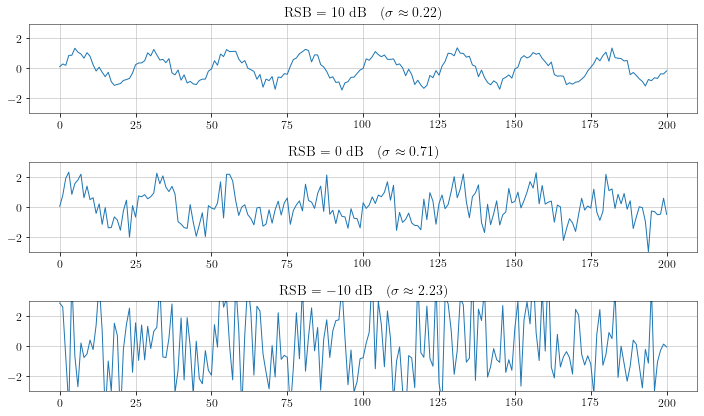

In [4]:
# Sinusoïde bruitée à différents RSB

# Signal non bruité
N = 201
n = np.arange(N)
x = np.sin(2*np.pi*n*0.04)
Px = np.linalg.norm(x)**2/N

# Différents RSB
snrs = [10, 0, -10]
fig = plt.figure(figsize=(10, 6))
i = 0
for snr in snrs:
    
    i += 1
    
    # Observations
    sig = np.sqrt( Px * 10**(-snr/10) )
    y = x + np.random.normal(0, sig, N)
    
    # Affichage
    ax = plt.subplot(3,1,i)
    for side in ['bottom', 'top', 'right', 'left']:
        ax.spines[side].set_color('k')
        ax.spines[side].set_linewidth(0.5)
    ax.set_ylim([-3, 3])
    ax.grid(linewidth=0.5)
    
    plt.plot(n, y, 'tab:blue', linewidth=1)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    title =  rf"RSB = ${snr}$ dB\quad$(\sigma\approx{sig:.2f})$"
    plt.title(title, fontsize=14)
    
plt.subplots_adjust(hspace=0.6)
plt.tight_layout()
plt.savefig("rsb.svg", bbox_inches='tight')